## 6. Random Forest Classifier

### 6.1 Packages importeren 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from preprocessing import(
    spacy_preprocessor,
    spacy_tokenizer,
)
from helpfuncties import load_dataset

### 6.2 Dataset inladen 

In [2]:
df = load_dataset()   
X = df["Omschrijving"]
y = df["Product"]

print("Dataset shape:", df.shape)

Dataset shape: (14816, 2)


### 6.3 Train-Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42, stratify=y)

### 6.4 Vocab size experiment 

In [4]:
vocab_sizes = [2000, 2500, 3000, 3500, 5000, 8000, 10000, 15000]
results = []

# Alle tokens verzamelen
all_tokens = []
for text in X_train:
    all_tokens.extend(spacy_tokenizer(text))

freq = Counter(all_tokens)

for size in vocab_sizes:
    print(f"Testen met vocab_size = {size}")

    top_words_size = [w.lower() for w, c in freq.most_common(size)]

    tfidf_tmp = TfidfVectorizer(
        preprocessor=spacy_preprocessor,
        tokenizer=spacy_tokenizer,
        token_pattern=None,
        analyzer="word",
        vocabulary=top_words_size,
        sublinear_tf=True
    )

    rf_tmp = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        n_estimators=300,
        max_depth=30,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt"
    )

    pipe_tmp = Pipeline([
        ("tfidf", tfidf_tmp),
        ("rf", rf_tmp)
    ])

    scores = cross_val_score(
        pipe_tmp, X_train, y_train,
        cv=5,
        scoring="f1_weighted",
        n_jobs=-1
    )

    mean_score = scores.mean()
    results.append((size, mean_score))

    print(f" --> F1-weighted: {mean_score:.4f}\n")

best_vocab_size, best_score = max(results, key=lambda x: x[1])

print("Beste vocabulary size:", best_vocab_size)
print("Beste baseline F1:", best_score)

Testen met vocab_size = 2000
 --> F1-weighted: 0.8112

Testen met vocab_size = 2500
 --> F1-weighted: 0.8074

Testen met vocab_size = 3000
 --> F1-weighted: 0.8054

Testen met vocab_size = 3500
 --> F1-weighted: 0.8036

Testen met vocab_size = 5000
 --> F1-weighted: 0.8011

Testen met vocab_size = 8000
 --> F1-weighted: 0.7931

Testen met vocab_size = 10000
 --> F1-weighted: 0.7889

Testen met vocab_size = 15000
 --> F1-weighted: 0.7796

Beste vocabulary size: 2000
Beste baseline F1: 0.8112187155765828


### 6.5 Definitieve vocab

In [5]:
best_top_words = [w.lower() for w, c in freq.most_common(best_vocab_size)]
best_top_words = list(dict.fromkeys(best_top_words))

print("Aantal woorden in beste vocab:", len(best_top_words))

Aantal woorden in beste vocab: 2000


### 6.6 Definitieve TF-IDF + Random Forest Pipeline

In [6]:
tfidf_final = TfidfVectorizer(
    preprocessor=spacy_preprocessor,
    tokenizer=spacy_tokenizer,
    token_pattern=None,
    analyzer="word",
    vocabulary=best_top_words,
    sublinear_tf=True
)

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_pipeline = Pipeline([
    ("tfidf", tfidf_final),
    ("rf", rf)
])

### 6.7 GridsearchCV

In [7]:
param_grid = {
    "rf__n_estimators": [200, 300, 500],
    "rf__max_depth": [20, 30, 40, 60],
    "rf__min_samples_split": [2, 4],
    "rf__min_samples_leaf": [1, 2],
    "rf__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring="f1_macro",
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("\nBeste parameters:", grid_search.best_params_)

Fitting 3 folds for each of 96 candidates, totalling 288 fits

Beste parameters: {'rf__max_depth': 40, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}


### 6.8 Cross-validation (betrouwbaarheid testen)

In [8]:
scores = cross_val_score(
    best_model,
    X_train, y_train,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Gemiddelde CV F1:", scores.mean())
print("CV scores:", scores)

Gemiddelde CV F1: 0.8274994518530443
CV scores: [0.82831238 0.84174775 0.81561073 0.82929375 0.82253266]


### 6.9 Evaluatie Modelprestaties 

#### 6.9.1 Voorspellingen

In [9]:
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)
y_pred_train = best_model.predict(X_train)

#### 6.9.2 Totale metrics

In [10]:
test_accuracy = accuracy_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test, average='weighted')
train_accuracy = accuracy_score(y_train, y_pred_train)
train_f1 = f1_score(y_train, y_pred_train, average='weighted')

print(f'Test Accuracy RF: {test_accuracy:.3f}')
print(f"Test F1 RF: {test_f1:.3f}")
print(f'Train Accuracy RF: {train_accuracy:.3f}')
print(f"Train F1 RF: {train_f1:.3f}")

Test Accuracy RF: 0.823
Test F1 RF: 0.821
Train Accuracy RF: 0.958
Train F1 RF: 0.958


#### 6.9.3 Classification report

In [11]:
print("\nClassification report Testset:\n")
print(classification_report(y_test, y_pred_test))


Classification report Testset:

                    precision    recall  f1-score   support

      Bankrekening       0.83      0.81      0.82       446
Consumentenkrediet       0.72      0.55      0.62       284
        Creditcard       0.75      0.79      0.77       564
         Hypotheek       0.89      0.93      0.91       994
           Incasso       0.83      0.82      0.82      1223
Kredietregistratie       0.80      0.82      0.81       934

          accuracy                           0.82      4445
         macro avg       0.81      0.79      0.79      4445
      weighted avg       0.82      0.82      0.82      4445



In [12]:
print("\nClassification report Trainset:\n")
print(classification_report(y_train, y_pred_train))


Classification report Trainset:

                    precision    recall  f1-score   support

      Bankrekening       0.97      0.97      0.97      1041
Consumentenkrediet       0.96      0.97      0.97       663
        Creditcard       0.95      0.95      0.95      1316
         Hypotheek       0.98      0.98      0.98      2320
           Incasso       0.96      0.94      0.95      2852
Kredietregistratie       0.93      0.95      0.94      2179

          accuracy                           0.96     10371
         macro avg       0.96      0.96      0.96     10371
      weighted avg       0.96      0.96      0.96     10371



#### 6.9.4 Confusion Matrix

[[ 363    1   44   17   11   10]
 [  10  155   21   25   48   25]
 [  27    8  446   10   35   38]
 [  15    5    7  927   22   18]
 [  17   24   40   44 1003   95]
 [   7   21   34   16   91  765]]


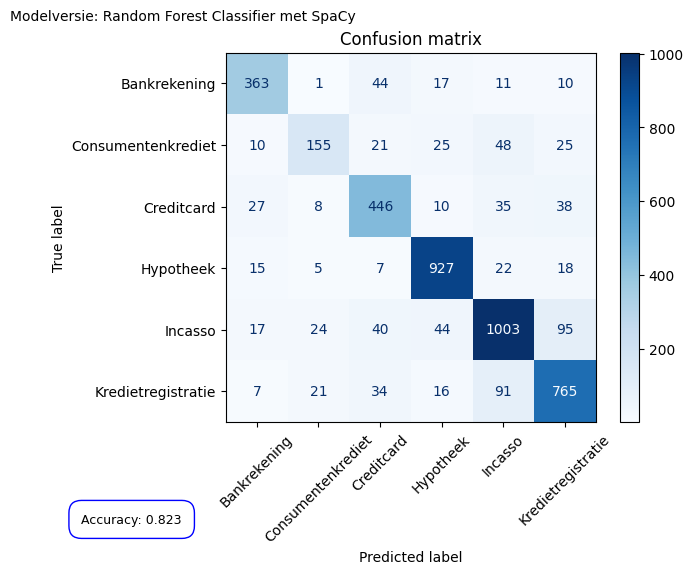

In [13]:
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    cmap='Blues'
)
plt.xticks(rotation=45)
plt.title('Confusion matrix')
plt.suptitle("Modelversie: Random Forest Classifier met SpaCy", fontsize=10, x=0.1, y=0.97) # ! naam aanpassen per modelversie
plt.figtext(0.02, -0.1, f"Accuracy: {test_accuracy:.3f}", ha='center', fontsize=9, color='black', bbox=dict(facecolor='none', edgecolor='blue', boxstyle='round,pad=1'))
plt.savefig("afbeeldingen/confusion_matrix_spacy_random_forest.png", dpi=300, bbox_inches='tight') # ! naam aanpassen per modelversie
plt.show()

#### 6.9.5 AUC-score (multiclass)

In [14]:
auc_rf = roc_auc_score(y_test, y_proba_test, multi_class='ovr')
print(f"AUC Random Forest Classifier: {auc_rf:.3f}")

AUC Random Forest Classifier: 0.964
